# Ensemble Soft Voting — HistGradientBoostingRegressor

Trains every combination in a 4×4×5×3 = 240-model hyperparameter grid and
combines their predictions with **inverse-validation-RMSE weighting**: each
model's contribution to the ensemble is proportional to `1 / val_RMSE`,
so stronger-validating models dominate the average.

Saves test-set predictions to `results/soft_voting_preds.npy` for
`model_comparison.ipynb`.

**Metrics scale:** monthly log-diff × 100 (percentage points of monthly PCE inflation).


In [3]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from itertools import product
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow._api.v2.experimental.numpy import random

sys.path.insert(0, os.path.dirname(os.path.abspath('__file__')))
from fred_md_utils import configure_plots, default_paths, get_splits

configure_plots()
VINTAGE_DIR, RESULTS_DIR = default_paths()


## Load splits

In [4]:
vintage_file, X_train, y_train, X_val, y_val, X_test, y_test, feature_names = get_splits(
    VINTAGE_DIR, horizon=1, n_lags=0,
)
print(f"Features: {len(feature_names)}  Train/Val/Test: {len(X_train)}/{len(X_val)}/{len(X_test)}")


  2026-04-MD.csv: URL returned HTML — vintage not yet published
Already have 2026-03-MD.csv

Dataset summary (PCEPI first-log-diff target, 1-month-ahead):
  Train :  768 obs  1959-01-01 -> 2022-12-01
  Val   :   29 obs  2023-01-01 -> 2025-05-01
  Test  :    7 obs  2025-06-01 -> 2025-12-01
  Features: 126 (126 base × 1 time steps)
Features: 126  Train/Val/Test: 768/29/7


## Train full grid and collect per-model val/test predictions

In [5]:
max_iter_grid = [100, 500, 1000]
max_depth_grid = [6, 7, 8, 9, 10]
learning_rate_grid = [.01, .03, .05, .07]
max_leaf_nodes_grid = [10, 20, 30]
min_samples_leaf_grid = [20, 35, 50]

val_preds_list  = []
test_preds_list = []
val_rmses       = []
configs         = []

n_total = (len(max_iter_grid) * len(learning_rate_grid)
           * len(max_leaf_nodes_grid) * len(min_samples_leaf_grid) * len(max_depth_grid))
print(f"Training {n_total} HistGradientBoostingRegressor models...")

for mi, lr, mln, msl, md in product(max_iter_grid, learning_rate_grid,
                                 max_leaf_nodes_grid, min_samples_leaf_grid, max_depth_grid):
    model = HistGradientBoostingRegressor(
        max_iter=mi, learning_rate=lr,
        max_leaf_nodes=mln, min_samples_leaf=msl,
        max_depth=md,
        l2_regularization=0.1,
        early_stopping=True, validation_fraction=0.15, n_iter_no_change=25,
        random_state=int(random.randint(0, 100)),
    )
    model.fit(X_train, y_train)
    vp = model.predict(X_val)
    tp = model.predict(X_test)
    val_preds_list.append(vp)
    test_preds_list.append(tp)
    val_rmses.append(float(np.sqrt(mean_squared_error(y_val, vp))))
    configs.append({'max_iter': mi, 'learning_rate': lr,
                    'max_leaf_nodes': mln, 'min_samples_leaf': msl})

    if len(configs) % 20 == 0:
        print(f"  {len(configs)}/{n_total} done")

val_preds_arr  = np.stack(val_preds_list)
test_preds_arr = np.stack(test_preds_list)
val_rmses      = np.array(val_rmses)
print(f"Finished {len(configs)} models.")


Training 540 HistGradientBoostingRegressor models...
  20/540 done
  40/540 done
  60/540 done
  80/540 done
  100/540 done
  120/540 done
  140/540 done
  160/540 done
  180/540 done
  200/540 done
  220/540 done
  240/540 done
  260/540 done
  280/540 done
  300/540 done
  320/540 done
  340/540 done
  360/540 done
  380/540 done
  400/540 done
  420/540 done
  440/540 done
  460/540 done
  480/540 done
  500/540 done
  520/540 done
  540/540 done
Finished 540 models.


## Combine with inverse-val-RMSE weights

In [6]:
weights = 1.0 / val_rmses
weights = weights / weights.sum()

ensemble_val_pred  = np.average(val_preds_arr,  axis=0, weights=weights)
ensemble_test_pred = np.average(test_preds_arr, axis=0, weights=weights)

# Equal-weight baseline for reference
equal_val_pred  = val_preds_arr.mean(axis=0)
equal_test_pred = test_preds_arr.mean(axis=0)

print(f"Individual val RMSE: min={val_rmses.min():.4f}  "
      f"median={np.median(val_rmses):.4f}  max={val_rmses.max():.4f}")
print(f"Equal-weight   val RMSE: {np.sqrt(mean_squared_error(y_val, equal_val_pred)):.4f}")
print(f"Weighted  val RMSE (soft vote): "
      f"{np.sqrt(mean_squared_error(y_val, ensemble_val_pred)):.4f}")


Individual val RMSE: min=0.0873  median=0.1264  max=0.2309
Equal-weight   val RMSE: 0.1127
Weighted  val RMSE (soft vote): 0.1082


### Top 10 configs by validation RMSE

In [7]:
top_df = (
    pd.DataFrame(configs)
      .assign(val_rmse=val_rmses, weight=weights)
      .sort_values('val_rmse')
      .head(10)
      .reset_index(drop=True)
)
print(top_df.to_string(index=False, float_format='{:.4f}'.format))


 max_iter  learning_rate  max_leaf_nodes  min_samples_leaf  val_rmse  weight
     1000         0.0300              20                35    0.0873  0.0027
      100         0.0300              30                35    0.0884  0.0027
      500         0.0300              20                35    0.0901  0.0026
      500         0.0700              30                35    0.0929  0.0025
      500         0.0100              30                50    0.0932  0.0025
     1000         0.0500              30                20    0.0938  0.0025
      100         0.0500              30                20    0.0938  0.0025
      100         0.0300              10                35    0.0943  0.0025
      100         0.0500              10                35    0.0944  0.0025
      100         0.0700              10                35    0.0955  0.0025


## Test-set metrics

In [8]:
def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    return {
        'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'MAE':  float(mean_absolute_error(y_true, y_pred)),
        'R²':   float(r2_score(y_true, y_pred)),
        'MAPE': float(np.mean(np.abs((y_true - y_pred) / (y_true + 1e-10))) * 100),
    }

val_m  = metrics(y_val,  ensemble_val_pred)
test_m = metrics(y_test, ensemble_test_pred)
naive_rmse = float(np.sqrt(mean_squared_error(y_val.iloc[1:], y_val.shift(1).dropna())))

print(f"Val  : RMSE={val_m['RMSE']:.4f}  MAE={val_m['MAE']:.4f}  R²={val_m['R²']:.4f}  MAPE={val_m['MAPE']:.2f}%")
print(f"Test : RMSE={test_m['RMSE']:.4f}  MAE={test_m['MAE']:.4f}  R²={test_m['R²']:.4f}  MAPE={test_m['MAPE']:.2f}%")
print(f"Naive RW (val reference) RMSE: {naive_rmse:.4f}")


Val  : RMSE=0.1082  MAE=0.0896  R²=0.1900  MAPE=204.10%
Test : RMSE=0.0920  MAE=0.0797  R²=-1.5973  MAPE=30.44%
Naive RW (val reference) RMSE: 0.1661


## Plot actual vs predicted

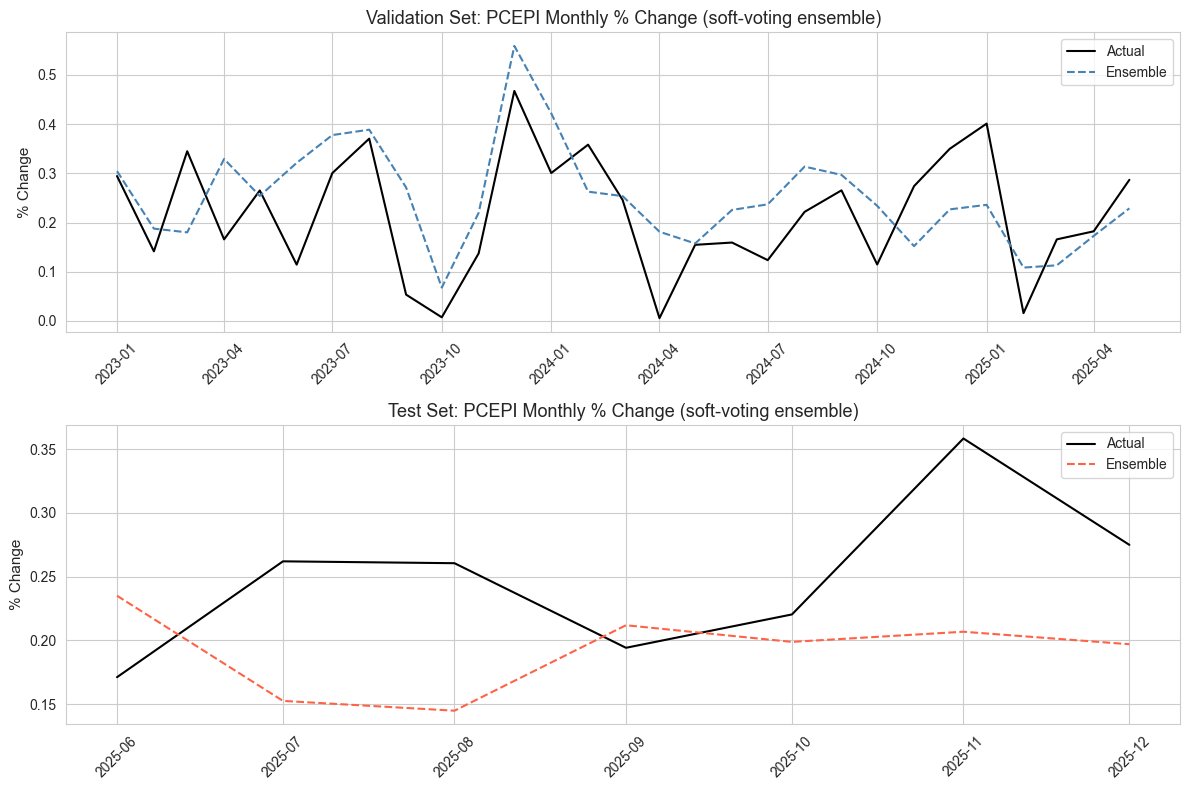

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(y_val.index, y_val.values,          label='Actual',    color='black')
axes[0].plot(y_val.index, ensemble_val_pred,     label='Ensemble',  color='steelblue', linestyle='--')
axes[0].set_title('Validation Set: PCEPI Monthly % Change (soft-voting ensemble)')
axes[0].set_ylabel('% Change'); axes[0].legend()
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(y_test.index, y_test.values,         label='Actual',    color='black')
axes[1].plot(y_test.index, ensemble_test_pred,    label='Ensemble',  color='tomato', linestyle='--')
axes[1].set_title('Test Set: PCEPI Monthly % Change (soft-voting ensemble)')
axes[1].set_ylabel('% Change'); axes[1].legend()
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


## Save test predictions for `model_comparison.ipynb`

In [22]:
os.makedirs(RESULTS_DIR, exist_ok=True)
np.save(os.path.join(RESULTS_DIR, 'soft_voting_preds.npy'), np.asarray(ensemble_test_pred))
np.save(os.path.join(RESULTS_DIR, 'soft_voting_dates.npy'),
        np.array(y_test.index, dtype='datetime64[ns]'))
print(f"Saved {len(ensemble_test_pred)} soft-voting predictions to {RESULTS_DIR}/soft_voting_preds.npy")
print(f"  {y_test.index.min().date()} -> {y_test.index.max().date()}")


Saved 7 soft-voting predictions to results/soft_voting_preds.npy
  2025-06-01 -> 2025-12-01
